#### We begin by importing essential Python libraries and configuring display and visualization settings for exploratory and predictive analysis.


In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
# -------------------------------
# Modeling & Metrics
# -------------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score, precision_score,
                             recall_score, f1_score, roc_curve, auc, classification_report,
                             confusion_matrix)
import statsmodels.api as sm
import xgboost as xgb
from imblearn.over_sampling import SMOTE

# Settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid", palette="pastel")

#### We begin by importing the Global Weather Repository dataset and inspecting its structure to understand available meteorological and air quality variables.

In [ ]:
# The original dataset is updated daily and available at:
# https://www.kaggle.com/datasets/nelgiriyewithana/global-weather-repository/data

# Load dataset and project script from Google Drive
!pip install gdown

# For reproducibility, we used a static snapshot of the dataset downloaded once and performed all analyses on this version
url = "https://drive.google.com/uc?id=1wC6FyEQwE0YzMiFUKJDjdy76I7zS0_tL"
df = pd.read_csv(url)

# Download and import project script
import gdown
file_id = "10ylXt5VlwQwuc5ZsHnUV68HGC_ampqLO"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "capstone_group04.py", quiet=False)

import capstone_group04

print(df.head())

Downloading...
From (original): https://drive.google.com/uc?id=10ylXt5VlwQwuc5ZsHnUV68HGC_ampqLO
From (redirected): https://drive.google.com/uc?id=10ylXt5VlwQwuc5ZsHnUV68HGC_ampqLO&confirm=t&uuid=51e7c6d5-3f57-424c-abec-ecee743893e5
To: /content/capstone_group04.py
100%|██████████| 1.80k/1.80k [00:00<00:00, 5.69MB/s]

       country     location_name  latitude  longitude        timezone  \
0  Afghanistan             Kabul     34.52      69.18      Asia/Kabul   
1      Albania            Tirana     41.33      19.82   Europe/Tirane   
2      Algeria           Algiers     36.76       3.05  Africa/Algiers   
3      Andorra  Andorra La Vella     42.50       1.52  Europe/Andorra   
4       Angola            Luanda     -8.84      13.23   Africa/Luanda   

   last_updated_epoch      last_updated  temperature_celsius  \
0          1715849100  2024-05-16 13:15                 26.6   
1          1715849100  2024-05-16 10:45                 19.0   
2          1715849100  2024-05-16 09:45                 23.0   
3          1715849100  2024-05-16 10:45                  6.3   
4          1715849100  2024-05-16 09:45                 26.0   

   temperature_fahrenheit condition_text  wind_mph  wind_kph  wind_degree  \
0                    79.8  Partly Cloudy       8.3      13.3          338   
1                    6

In [ ]:
# -------------------------------
# Dataset Overview
# -------------------------------
# Goal: Quickly inspect structure, types, missing data, and sample records to inform data cleaning

def show_dataset_overview(df):
    """Display shape, types, missing values, unique values, and sample rows of a DataFrame."""
    print(f"Dataset Shape: {df.shape}\n")

    print("Data Types:")
    display(df.dtypes)

    print("\nMissing Values per Column:")
    display(df.isnull().sum())

    print("\nUnique Values per Column:")
    display(df.nunique())

    print("\nFirst 5 Rows:")
    display(df.head())

# Call the function
show_dataset_overview(df)


Dataset Shape: (98604, 41)

Data Types:


,0
country,object
location_name,object
latitude,float64
longitude,float64
timezone,object
last_updated_epoch,int64
last_updated,object
temperature_celsius,float64
temperature_fahrenheit,float64
condition_text,object



Missing Values per Column:


,0
country,0
location_name,0
latitude,0
longitude,0
timezone,0
last_updated_epoch,0
last_updated,0
temperature_celsius,0
temperature_fahrenheit,0
condition_text,0



Unique Values per Column:


,0
country,211
location_name,254
latitude,394
longitude,399
timezone,197
last_updated_epoch,960
last_updated,16734
temperature_celsius,655
temperature_fahrenheit,1080
condition_text,47



First 5 Rows:


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,8.3,13.3,338,NNW,1012.0,29.89,0.0,0.00,24,30,25.3,77.5,10.0,6.0,7.0,9.5,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,6.9,11.2,320,NW,1012.0,29.88,0.1,0.00,94,75,19.0,66.2,10.0,6.0,5.0,11.4,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,9.4,15.1,280,W,1011.0,29.85,0.0,0.00,29,0,24.6,76.4,10.0,6.0,5.0,13.9,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,7.4,11.9,215,SW,1007.0,29.75,0.3,0.01,61,100,3.8,38.9,2.0,1.0,2.0,8.5,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,8.1,13.0,150,SSE,1011.0,29.85,0.0,0.00,89,50,28.7,83.6,10.0,6.0,8.0,12.5,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


#### To keep the data consistent and reliable, we only include countries that have 500 or more weather records. This makes sure our analysis focuses on countries with enough data.

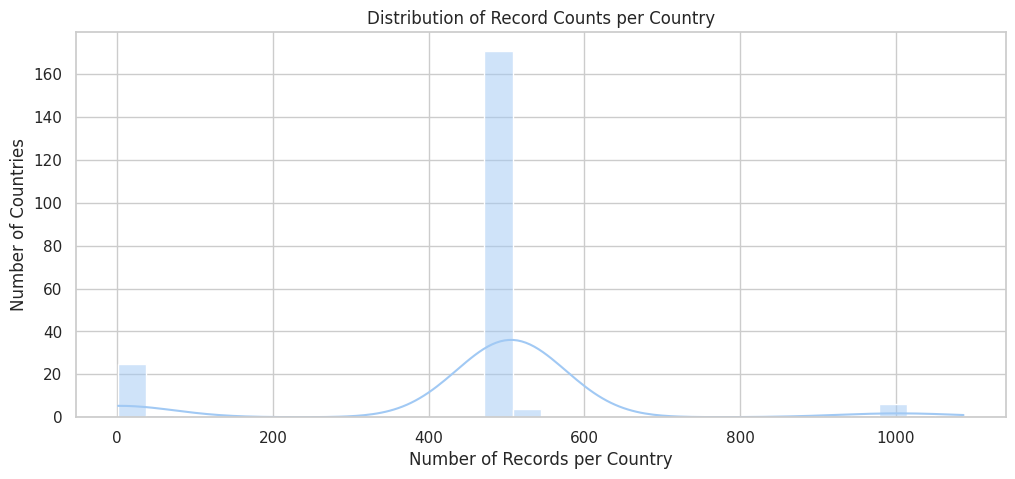

Before filtering: 98604 records
After filtering: 98531 records
Countries kept: 185

Countries removed (less than {min_records} records):


,count
country,
Cote d'Ivoire,46
USA United States of America,3
Lao People's Democratic Republic,1
Libya,1
Kosovo,1
Togo,1
Malásia,1
Komoren,1
كولومبيا,1



Filtered dataset saved as 'filtered_weather_data.csv'


In [ ]:
# -------------------------------
# Country Distribution & Filtering
# -------------------------------

def filter_countries_by_records(df, min_records=500, save_path=None):
    """
    Filter DataFrame to include only countries with at least `min_records` entries.

    Parameters:
        df (pd.DataFrame): Original dataset
        min_records (int): Minimum number of records to keep a country
        save_path (str, optional): Path to save the filtered dataset as CSV

    Returns:
        pd.DataFrame: Filtered DataFrame
        pd.Series: Countries removed (less than min_records)
    """
    # Count records per country
    country_counts = df['country'].value_counts()

    # Visualize distribution of records per country
    plt.figure(figsize=(12,5))
    sns.histplot(country_counts, bins=30, kde=True)
    plt.title("Distribution of Record Counts per Country")
    plt.xlabel("Number of Records per Country")
    plt.ylabel("Number of Countries")
    plt.show()

    # Filter countries with sufficient records
    valid_countries = country_counts[country_counts >= min_records].index
    df_filtered = df[df['country'].isin(valid_countries)].copy()

    # Summary
    print(f"Before filtering: {len(df)} records")
    print(f"After filtering: {len(df_filtered)} records")
    print(f"Countries kept: {df_filtered['country'].nunique()}")

    # List removed countries
    removed_countries = country_counts[country_counts < min_records]
    if not removed_countries.empty:
        print("\nCountries removed (less than {min_records} records):")
        display(removed_countries)

    # Save filtered dataset if path provided
    if save_path:
        df_filtered.to_csv(save_path, index=False)
        print(f"\nFiltered dataset saved as '{save_path}'")

    return df_filtered, removed_countries

# Apply function
df_filtered, removed_countries = filter_countries_by_records(df, min_records=500, save_path='filtered_weather_data.csv')


#### We compute descriptive statistics to understand the central tendencies and variability of the key meteorological features.

In [ ]:
# ===============================
# Descriptive Statistics & Feature Distributions
# ===============================

features = [
    'temperature_celsius', 'humidity', 'precip_mm', 'cloud',
    'pressure_mb', 'uv_index', 'wind_kph', 'air_quality_PM2.5', 'air_quality_PM10'
]

# Display summary statistics
print("Summary Statistics for Selected Features:")
display(df_filtered[features].describe().T)  # Transposed for better readability


Summary Statistics for Selected Features:


,count,mean,std,min,25%,50%,75%,max
temperature_celsius,98531.0,22.762491,8.889935,-24.900,18.10,24.900,28.300,49.20
humidity,98531.0,64.248003,24.170029,2.000,47.00,69.000,84.000,100.00
precip_mm,98531.0,0.141389,0.603095,0.000,0.00,0.000,0.030,42.24
cloud,98531.0,39.337366,33.746473,0.000,0.00,26.000,75.000,100.00
pressure_mb,98531.0,1013.984817,11.344283,947.000,1010.00,1013.000,1018.000,3006.00
uv_index,98531.0,3.865820,3.618322,0.000,0.50,3.000,6.900,16.30
wind_kph,98531.0,13.250973,12.636950,3.600,6.50,11.200,18.400,2963.20
air_quality_PM2.5,98531.0,26.055641,40.667722,0.168,7.40,15.010,29.785,1614.10
air_quality_PM10,98531.0,53.479783,163.458546,-1848.150,10.73,22.015,45.695,6037.29


#### We visualize the distributions and outliers for important meteorological and air quality variables using histograms and boxplots.

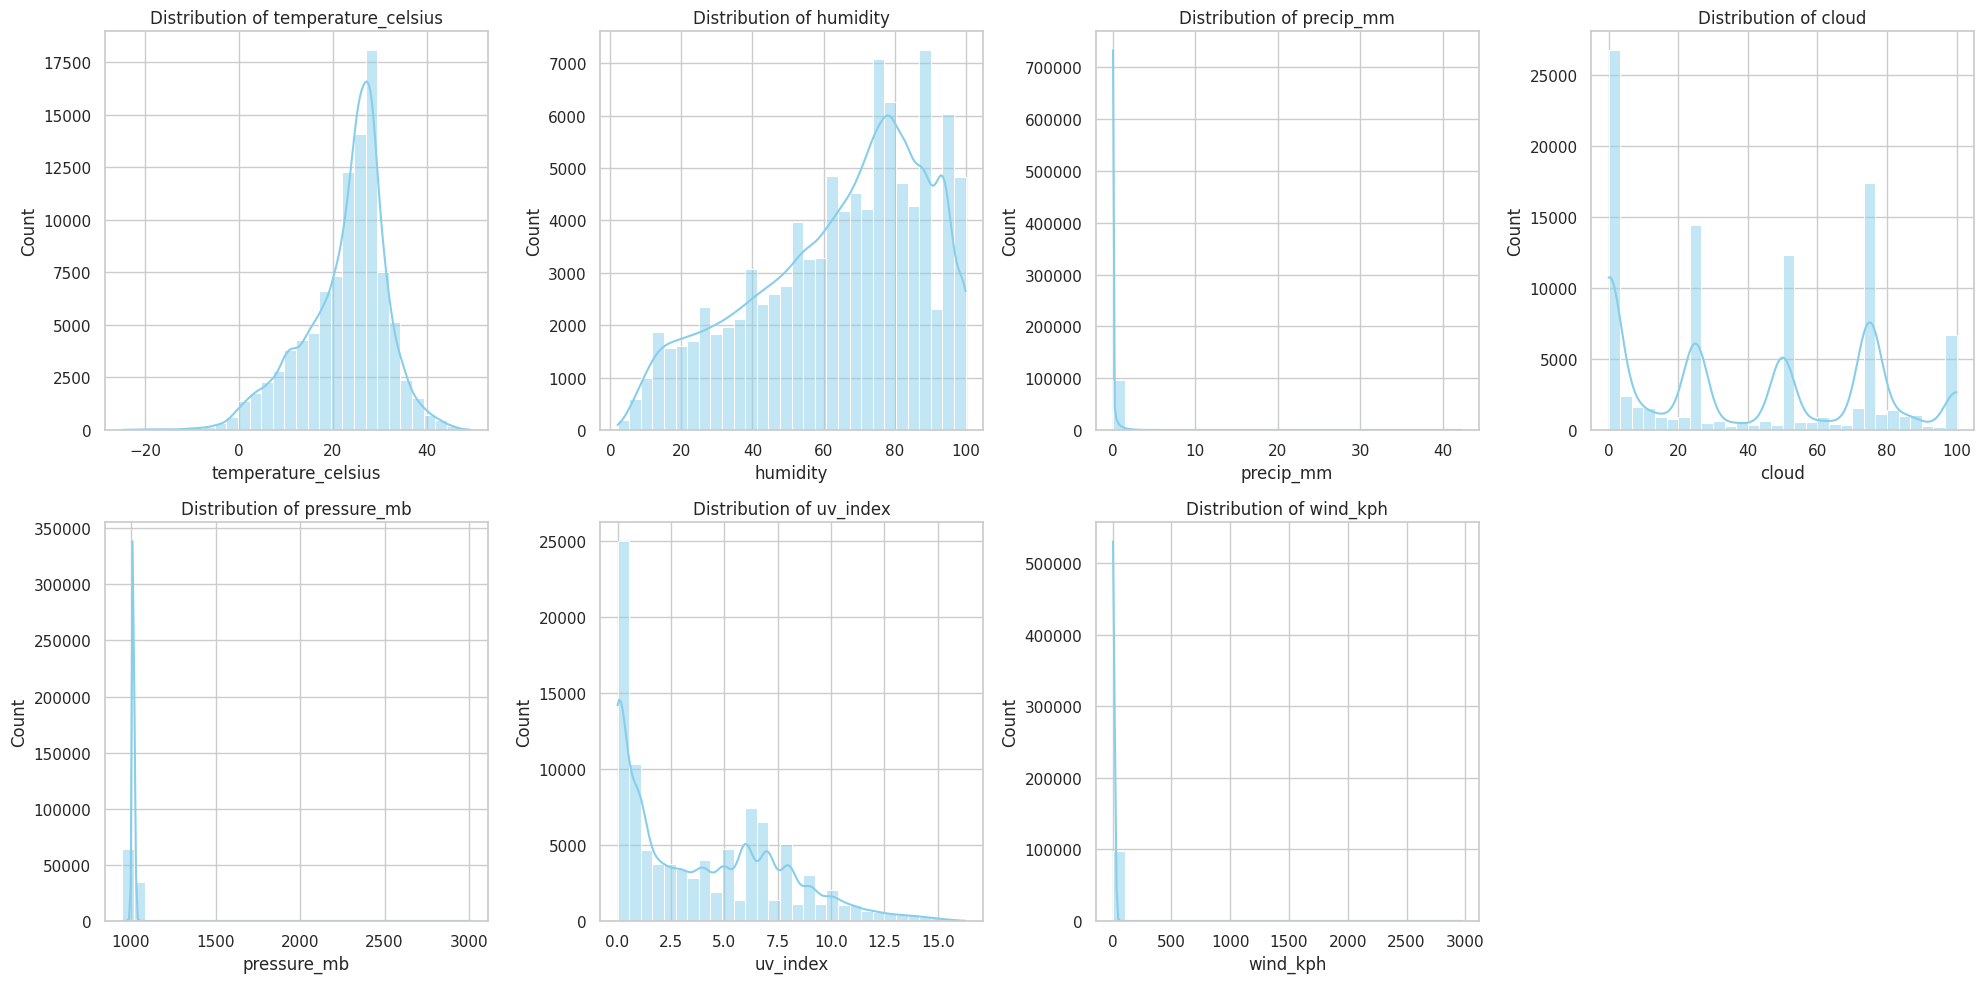

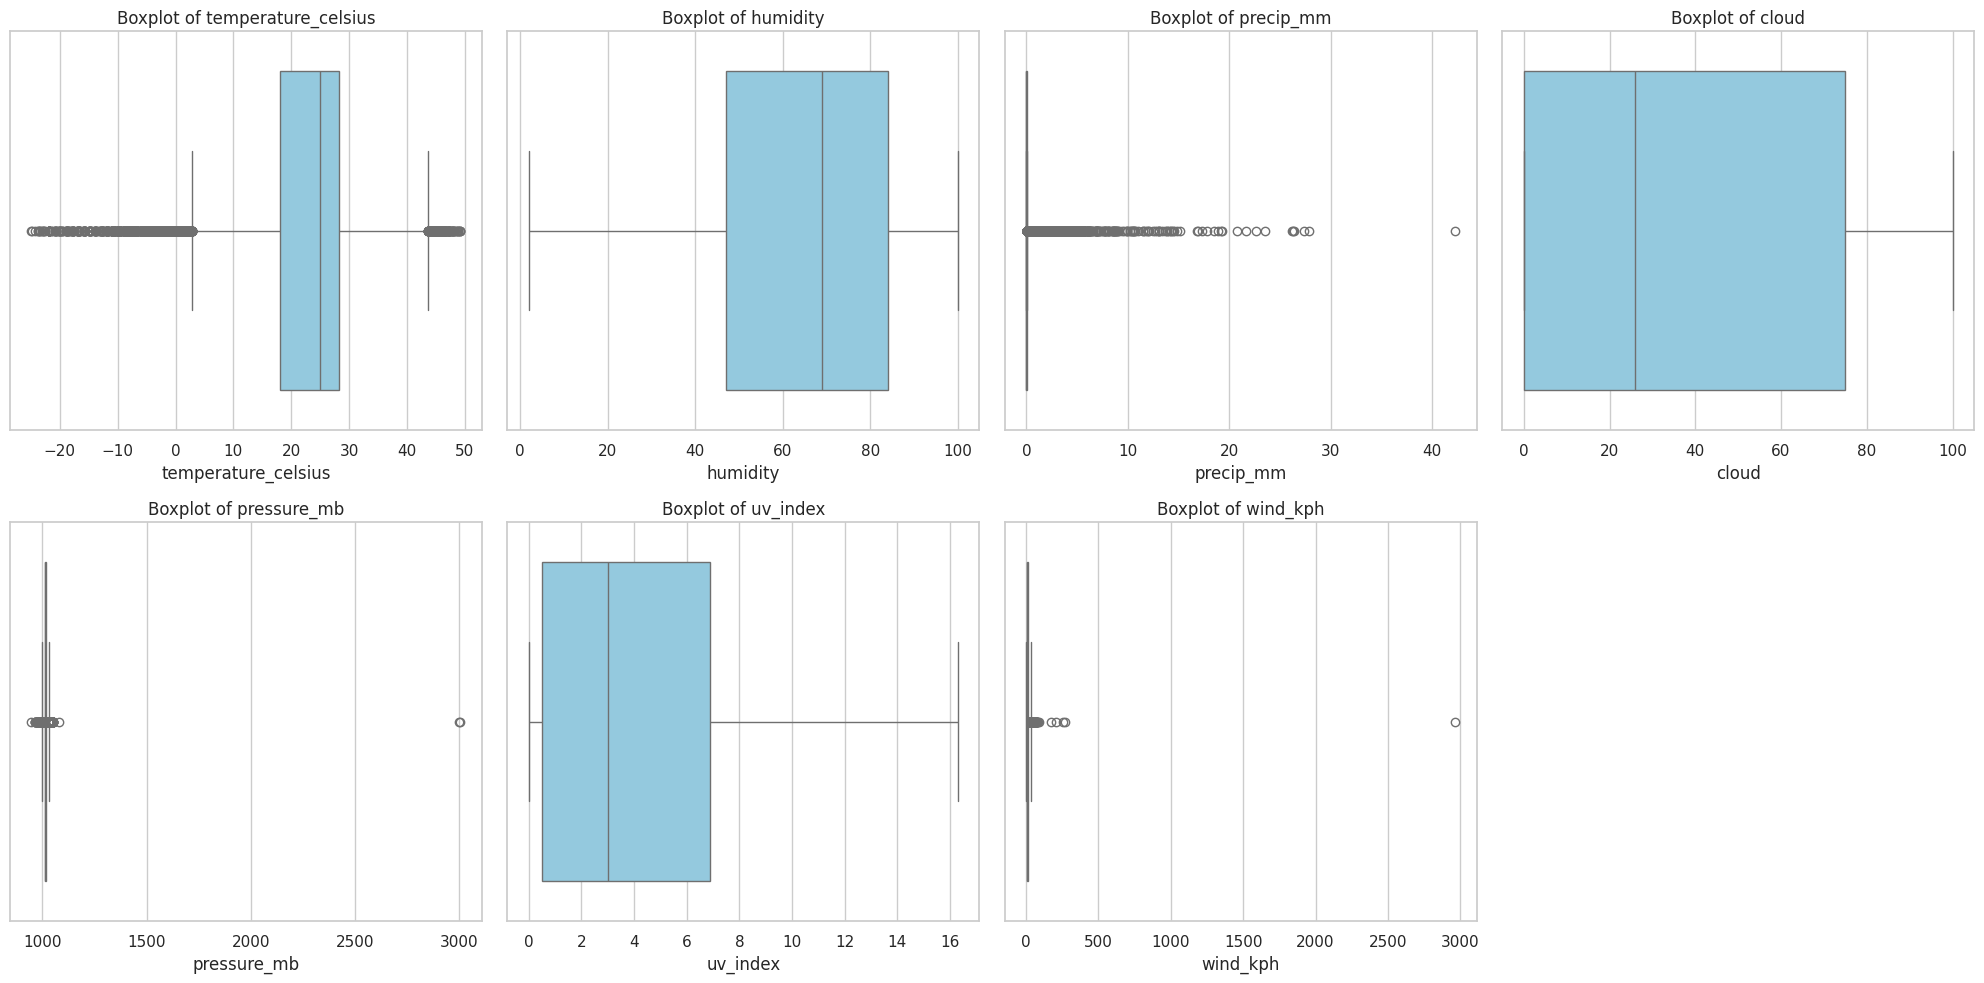

In [ ]:
# ===============================
# Feature Visualization
# ===============================
# Method: Using custom function from capstone_group04.py to summarize distributions

features = [
    'temperature_celsius', 'humidity', 'precip_mm',
    'cloud', 'pressure_mb', 'uv_index', 'wind_kph'
]

# Visualize distributions and outliers
capstone_group04.summarize_feature_distribution(df_filtered, features)


#### To improve model accuracy, we remove extreme values from numerical features using the Interquartile Range (IQR) method.

In [ ]:
# ===============================
# Remove Outliers
# ===============================

df_no_outliers = capstone_group04.clean_outliers(df_filtered, features)

print(f"Original dataset: {len(df_filtered)} rows")
print(f"After removing outliers: {len(df_no_outliers)} rows")


Original dataset: 98531 rows
After removing outliers: 72225 rows


/tmp/ipython-input-379542499.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


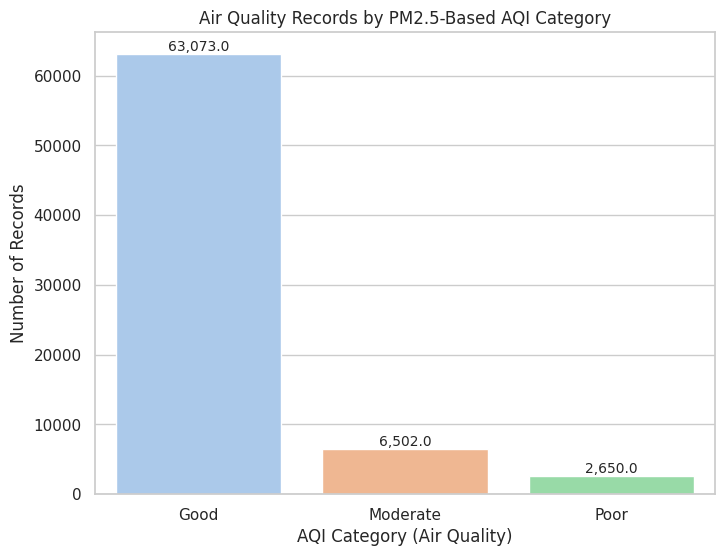

Proportion of Records per AQI Category:


,proportion
aqi_category,
Good,0.873285
Moderate,0.090024
Poor,0.036691


In [ ]:
# ===============================
# Target Relationships: AQI Categories
# ===============================
# Categorize PM2.5 into AQI categories (Good, Moderate, Poor)
# and visualize class distribution to understand class imbalance.

def categorize_aqi(pm25):
    """Categorize PM2.5 levels into AQI categories: Good, Moderate, Poor."""
    if pm25 <= 50:
        return 'Good'
    elif pm25 <= 100:
        return 'Moderate'
    else:
        return 'Poor'

# Apply categorization
df_no_outliers['aqi_category'] = df_no_outliers['air_quality_PM2.5'].apply(categorize_aqi)

# Visualize class counts
plt.figure(figsize=(8,6))
sns.countplot(
    x='aqi_category',
    data=df_no_outliers,
    palette='pastel',
    order=['Good', 'Moderate', 'Poor']  # ensures consistent order
)

# Set informative title and axis labels
plt.title("Air Quality Records by PM2.5-Based AQI Category")
plt.xlabel("AQI Category (Air Quality)")
plt.ylabel("Number of Records")

# Annotate counts on bars
for p in plt.gca().patches:
    plt.gca().annotate(
        f"{p.get_height():,}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        fontsize=10
    )

plt.show()

# Display proportions of each class
aqi_proportions = df_no_outliers['aqi_category'].value_counts(normalize=True)
print("Proportion of Records per AQI Category:")
display(aqi_proportions)


/tmp/ipython-input-3322188819.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-3322188819.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


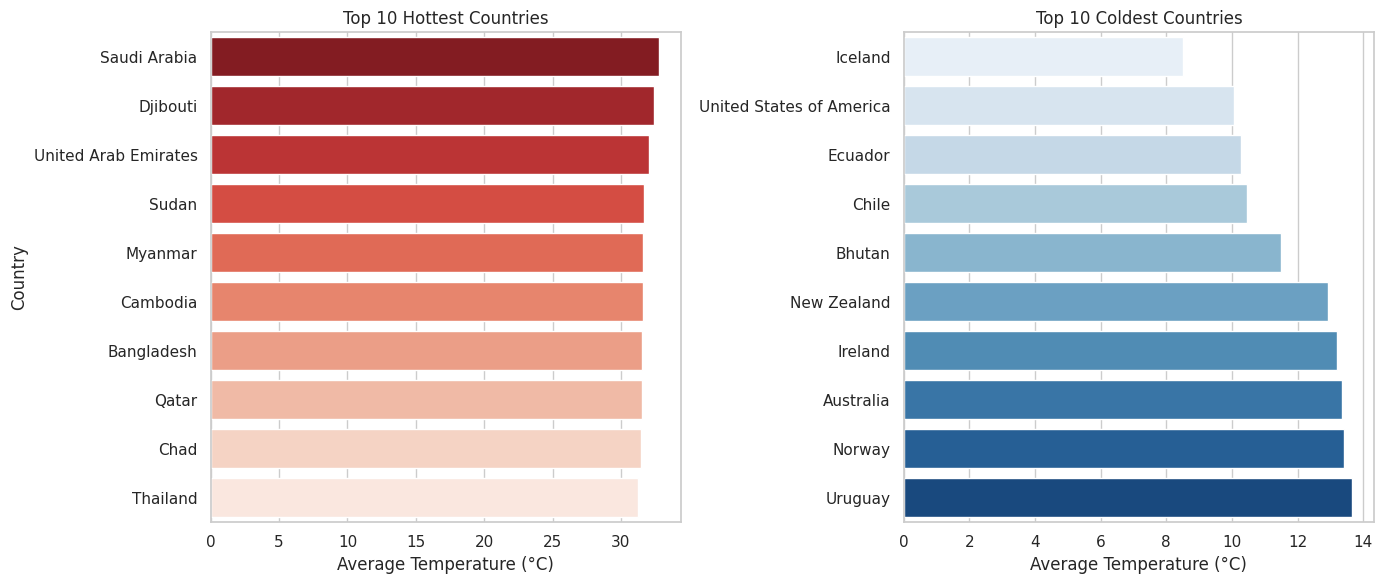

In [ ]:
# ===============================
# Geographical & Temporal Features: Hottest & Coldest Countries
# ===============================

avg_temp_country = (
    df_no_outliers
    .groupby('country')['temperature_celsius']
    .mean()
    .reset_index()
    .rename(columns={'temperature_celsius': 'avg_temperature_celsius'})
)

# Top 10 hottest and coldest countries
top10_hot = avg_temp_country.sort_values('avg_temperature_celsius', ascending=False).head(10)
top10_cold = avg_temp_country.sort_values('avg_temperature_celsius', ascending=True).head(10)

# Plot
plt.figure(figsize=(14,6))

# Hottest countries
plt.subplot(1, 2, 1)
sns.barplot(
    x='avg_temperature_celsius',
    y='country',
    data=top10_hot,
    palette='Reds_r'
)
plt.title("Top 10 Hottest Countries")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Country")

# Coldest countries
plt.subplot(1, 2, 2)
sns.barplot(
    x='avg_temperature_celsius',
    y='country',
    data=top10_cold,
    palette='Blues'
)
plt.title("Top 10 Coldest Countries")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("")

plt.tight_layout()
plt.show()


#### The correlation heatmap reveals linear relationships among meteorological and air quality parameters. It helps identify features with strong interdependence.

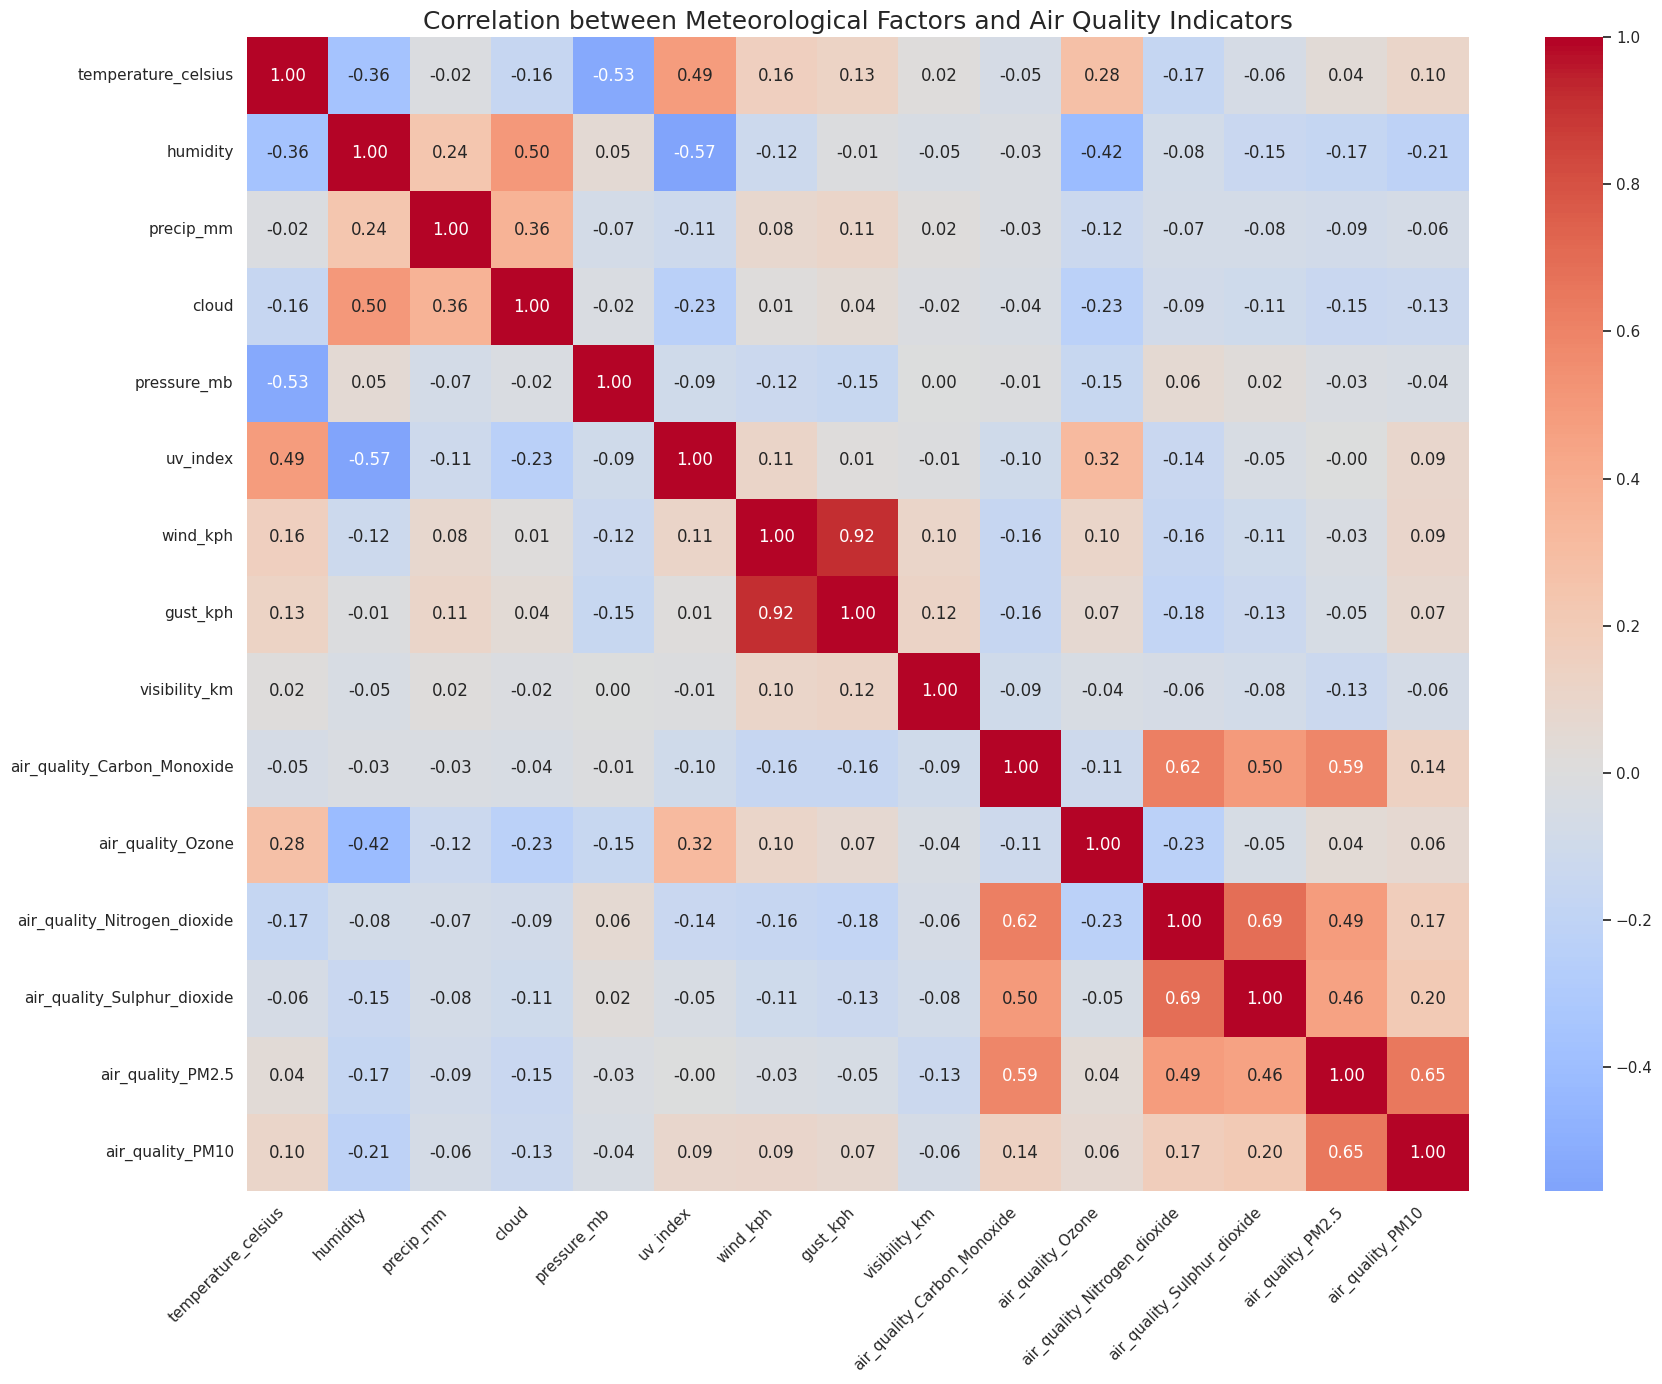

,temperature_celsius,humidity,precip_mm,cloud,pressure_mb,uv_index,wind_kph,gust_kph,visibility_km,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10
temperature_celsius,1.000000,-0.362757,-0.020830,-0.160463,-0.526928,0.488969,0.156443,0.132916,0.016877,-0.054494,0.277076,-0.166309,-0.057919,0.035318,0.103292
humidity,-0.362757,1.000000,0.239240,0.497997,0.050147,-0.569035,-0.120350,-0.008174,-0.047119,-0.026924,-0.421313,-0.079525,-0.145139,-0.168169,-0.207646
precip_mm,-0.020830,0.239240,1.000000,0.360710,-0.066946,-0.111065,0.083169,0.107196,0.015074,-0.029355,-0.122390,-0.069853,-0.076232,-0.087561,-0.063253
cloud,-0.160463,0.497997,0.360710,1.000000,-0.024556,-0.234754,0.012714,0.044775,-0.020125,-0.039326,-0.229518,-0.085767,-0.106932,-0.145160,-0.130530
pressure_mb,-0.526928,0.050147,-0.066946,-0.024556,1.000000,-0.094845,-0.122201,-0.151155,0.000709,-0.008321,-0.150850,0.062134,0.024563,-0.028800,-0.039939
uv_index,0.488969,-0.569035,-0.111065,-0.234754,-0.094845,1.000000,0.112828,0.007854,-0.006239,-0.103085,0.317045,-0.142819,-0.045842,-0.004648,0.087858
wind_kph,0.156443,-0.120350,0.083169,0.012714,-0.122201,0.112828,1.000000,0.917475,0.102151,-0.157837,0.104067,-0.159797,-0.106407,-0.033966,0.094027
gust_kph,0.132916,-0.008174,0.107196,0.044775,-0.151155,0.007854,0.917475,1.000000,0.120715,-0.163016,0.066611,-0.182389,-0.131831,-0.053293,0.071849
visibility_km,0.016877,-0.047119,0.015074,-0.020125,0.000709,-0.006239,0.102151,0.120715,1.000000,-0.092428,-0.044378,-0.058072,-0.079157,-0.130824,-0.062656
air_quality_Carbon_Monoxide,-0.054494,-0.026924,-0.029355,-0.039326,-0.008321,-0.103085,-0.157837,-0.163016,-0.092428,1.000000,-0.112096,0.622302,0.495420,0.586318,0.143727


In [ ]:
# ===============================
# Question 1: Correlation between Meteorological Factors and Air Quality
# ===============================

selected_columns = [
    'temperature_celsius', 'humidity', 'precip_mm', 'cloud',
    'pressure_mb', 'uv_index', 'wind_kph', 'gust_kph', 'visibility_km',
    'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5', 'air_quality_PM10'
]

# Compute correlation matrix
corr_matrix = df_no_outliers[selected_columns].corr()

# Plot heatmap
plt.figure(figsize=(18,14))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    xticklabels=selected_columns,
    yticklabels=selected_columns
)
plt.title("Correlation between Meteorological Factors and Air Quality Indicators", fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Display correlation matrix for reference
corr_matrix


#### We analyze the frequency of top weather conditions across the dataset to observe dominant climate patterns.

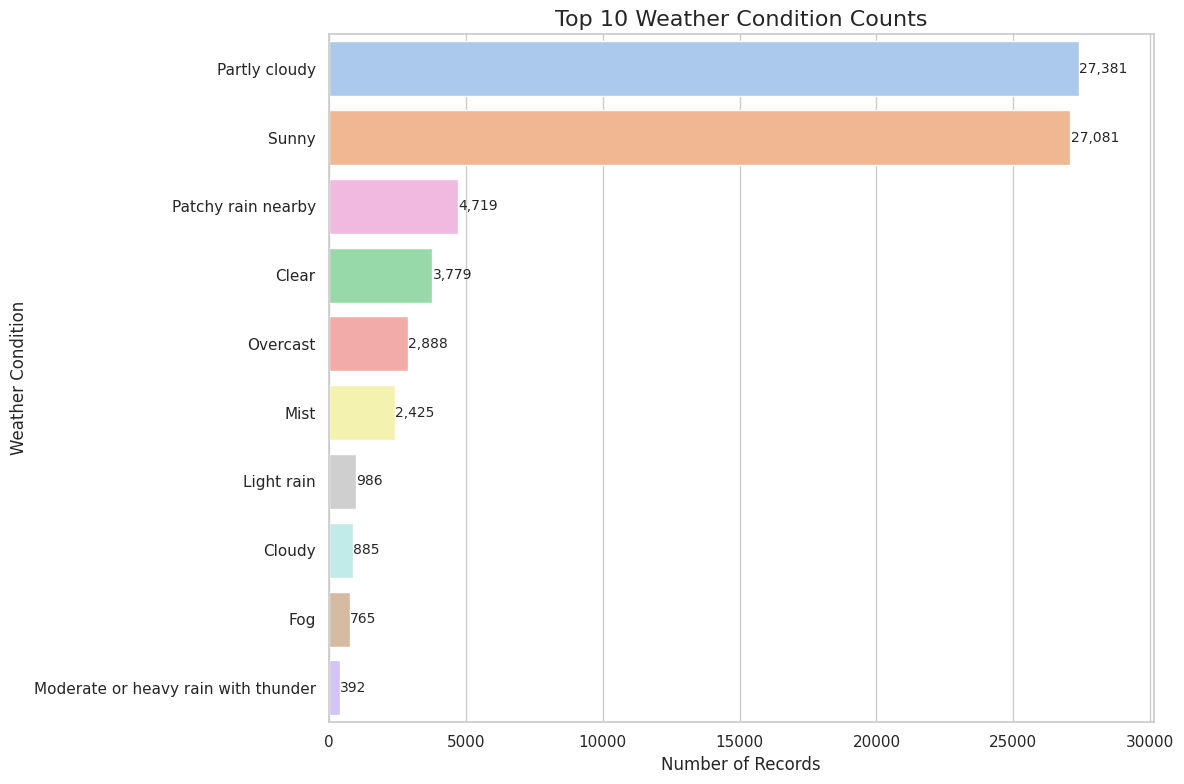

In [ ]:
# ===============================
# Top 10 Weather Condition Counts
# ===============================

# Standardize 'condition_text' (capitalize first letter, strip spaces)
df_no_outliers['condition_text_clean'] = df_no_outliers['condition_text'].str.strip().str.capitalize()

# Identify top 10 most frequent conditions
top_10_conditions = df_no_outliers['condition_text_clean'].value_counts().nlargest(10).index

# Filter dataset for top 10 conditions
df_top_10_conditions = df_no_outliers[df_no_outliers['condition_text_clean'].isin(top_10_conditions)].copy()

# Plot horizontal countplot
plt.figure(figsize=(12, 8))
ax = sns.countplot(
    y='condition_text_clean',
    data=df_top_10_conditions,
    order=top_10_conditions,
    palette='pastel',
    hue='condition_text_clean',
    legend=False
)

# Annotate counts on bars
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 5, p.get_y() + p.get_height()/2, f"{int(width):,}",
            va='center', fontsize=10)

# Labels and title
plt.title("Top 10 Weather Condition Counts", fontsize=16)
plt.xlabel("Number of Records", fontsize=12)
plt.ylabel("Weather Condition", fontsize=12)

# Extend x-axis slightly to avoid overlap with annotations
plt.xlim(0, df_top_10_conditions['condition_text_clean'].value_counts().max() * 1.1)

plt.tight_layout()
plt.show()


#### We apply Multiple Linear Regression to examine how meteorological and air quality features collectively influence temperature variations.

Multiple Linear Regression Results (Important Features Only):


,Feature,Coefficient
0,pressure_mb,-3.666
1,uv_index,2.564
2,wind_mph,5.256
3,cloud,-0.260
4,gust_mph,0.685
5,humidity,-1.206
6,wind_kph,-5.601
7,latitude,-1.282
8,air_quality_PM10,0.323
9,air_quality_PM2.5,-0.306


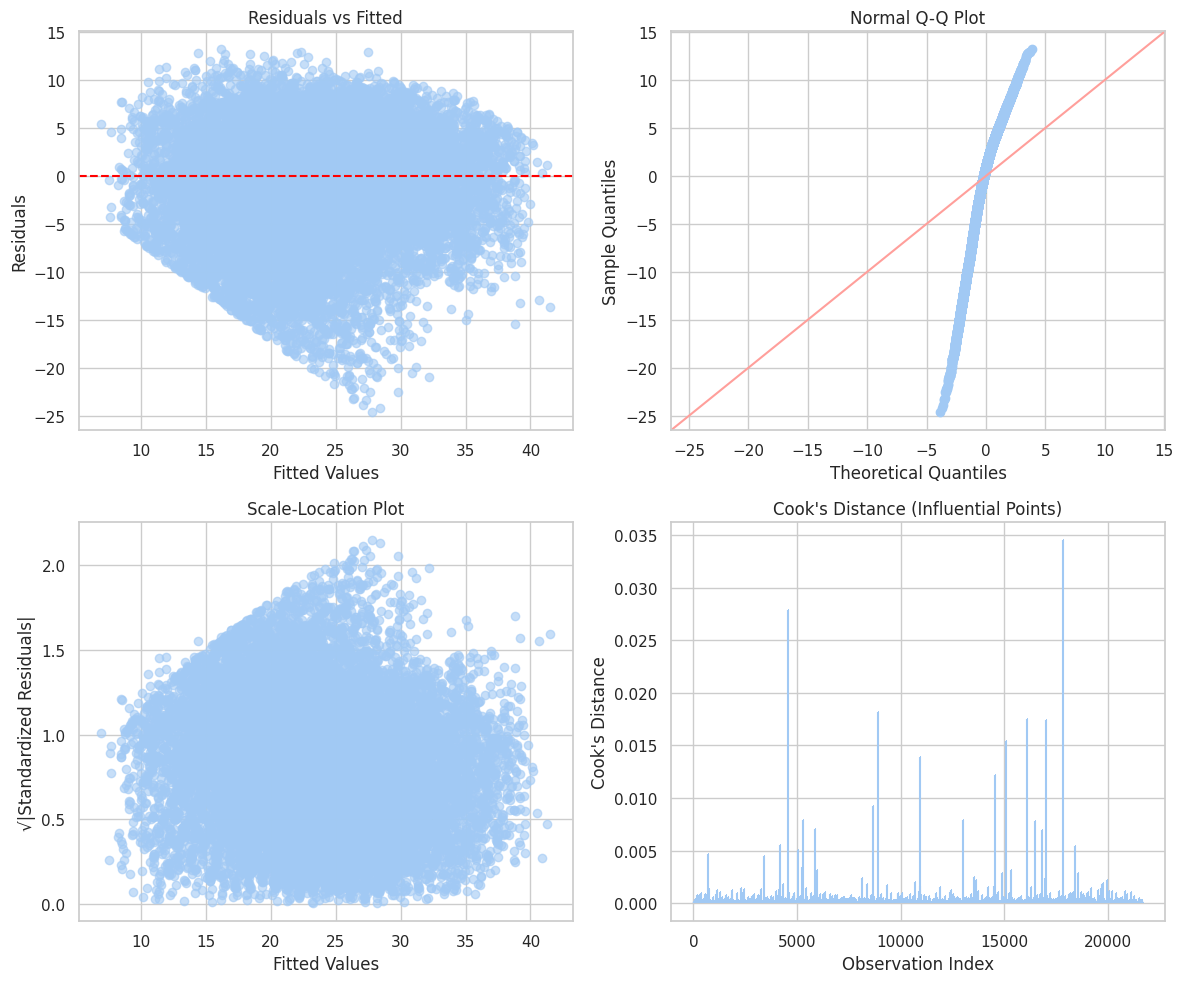

In [ ]:
# Question 2: How effectively can temperature be predicted using meteorological and air quality variables, and which factors contribute most significantly to daily temperature variations?

# =============================================
# Model 1: Multiple Linear Regression - Temperature Prediction
# =============================================

# ---------------------------------------------
# 1. Select important features
# ---------------------------------------------
important_features = [
    'pressure_mb', 'uv_index', 'wind_mph', 'cloud', 'gust_mph',
    'humidity', 'wind_kph', 'latitude', 'air_quality_PM10', 'air_quality_PM2.5'
]

# ---------------------------------------------
# 2. Prepare features and target
# ---------------------------------------------
X = df_no_outliers[important_features]
y = df_no_outliers['temperature_celsius']

# Drop missing values
df_multi = pd.concat([X, y], axis=1).dropna()
X = df_multi[important_features]
y = df_multi['temperature_celsius']

# ---------------------------------------------
# 3. Scale features
# ---------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------------------------
# 4. Train-test split
# ---------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

# ---------------------------------------------
# 5. Train model
# ---------------------------------------------
multi_lr = LinearRegression()
multi_lr.fit(X_train, y_train)

# ---------------------------------------------
# 6. Predictions and evaluation
# ---------------------------------------------
y_pred = multi_lr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# ---------------------------------------------
# 7. Combine coefficients and metrics
# ---------------------------------------------
results_df = pd.DataFrame({
    'Feature': important_features,
    'Coefficient': multi_lr.coef_.round(3)
})

evaluation_df = pd.DataFrame({
    'Feature': ['Intercept', 'RMSE', 'R²'],
    'Coefficient': [round(multi_lr.intercept_, 3), round(rmse, 3), round(r2, 3)]
})

final_results = pd.concat([results_df, evaluation_df], ignore_index=True)

print("Multiple Linear Regression Results (Important Features Only):")
display(final_results)

# ---------------------------------------------
# 8. Diagnostic Plots (Fast 2x2 Layout)
# ---------------------------------------------
# Residuals and fitted values
residuals = y_test - y_pred
fitted = y_pred
standardized_residuals = (residuals - np.mean(residuals)) / np.std(residuals)

# Cook's distance
model = sm.OLS(y_test, sm.add_constant(X_test)).fit()
influence = model.get_influence()
cooks_d, _ = influence.cooks_distance

# 2x2 figure
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Residuals vs Fitted
axs[0, 0].scatter(fitted, residuals, alpha=0.6)
axs[0, 0].axhline(y=0, color='red', linestyle='--')
axs[0, 0].set_xlabel('Fitted Values')
axs[0, 0].set_ylabel('Residuals')
axs[0, 0].set_title('Residuals vs Fitted')

# Normal Q-Q Plot
sm.qqplot(residuals, line='45', ax=axs[0, 1])
axs[0, 1].set_title('Normal Q-Q Plot')

# Scale-Location Plot
axs[1, 0].scatter(fitted, np.sqrt(np.abs(standardized_residuals)), alpha=0.6)
axs[1, 0].set_xlabel('Fitted Values')
axs[1, 0].set_ylabel('√|Standardized Residuals|')
axs[1, 0].set_title('Scale-Location Plot')

# Cook's Distance Plot
axs[1, 1].stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",", basefmt=" ")
axs[1, 1].set_xlabel('Observation Index')
axs[1, 1].set_ylabel("Cook's Distance")
axs[1, 1].set_title("Cook's Distance (Influential Points)")

plt.tight_layout()
plt.show()

#### We develop a Logistic Regression model to predict the likelihood of rainfall based on meteorological and air quality indicators.

Logistic Regression Performance:
Accuracy: 0.756
Precision: 0.419
Recall: 0.813
F1 Score: 0.553
ROC AUC: 0.842


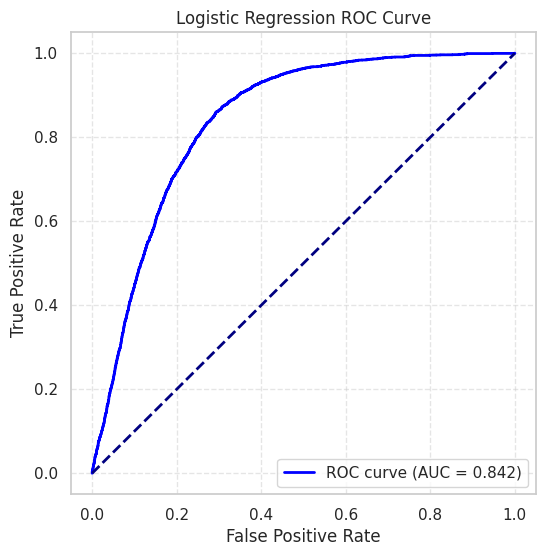

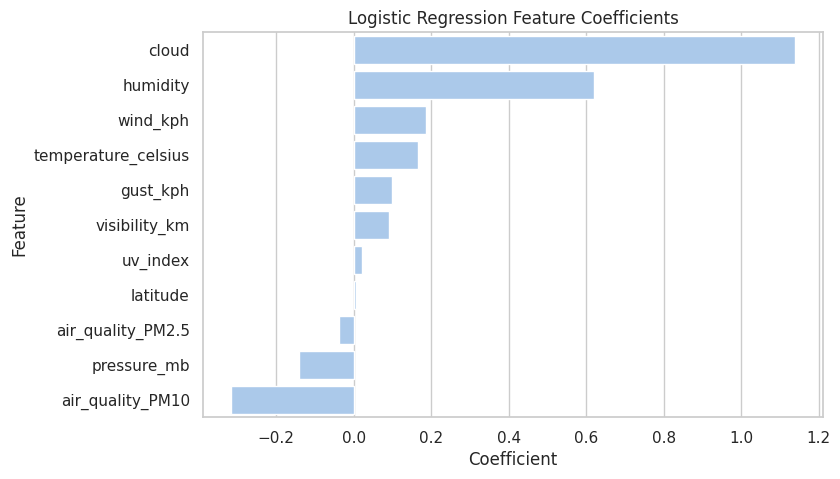

In [ ]:
# Question 3: Can meteorological and air quality variables accurately predict rainfall, and which factors are most influential in determining rain events?

# =============================================
# Model 2: Logistic Regression - Rain Prediction
# =============================================
# Target: Rain occurrence
df_no_outliers['rain'] = (df_no_outliers['precip_mm'] > 0).astype(int)

# Features
features = ['temperature_celsius', 'humidity', 'cloud', 'pressure_mb',
            'uv_index', 'wind_kph', 'gust_kph', 'visibility_km',
            'latitude', 'air_quality_PM2.5', 'air_quality_PM10']

X = df_no_outliers[features]
y = df_no_outliers['rain']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression with class balancing
log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)
log_reg.fit(X_train_scaled, y_train)

# Predictions
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("Logistic Regression Performance:")
capstone_group04.evaluate_classification_model(y_test, y_pred, y_prob)

# Compute values for ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# ROC Curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Feature Coefficients
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df)
plt.title("Logistic Regression Feature Coefficients")
plt.show()

#### We enhance rain prediction performance using XGBoost, a gradient boosting algorithm, to capture nonlinear feature interactions.

XGBoost Performance:
Accuracy: 0.876
Precision: 0.709
Recall: 0.568
F1 Score: 0.631
ROC AUC: 0.922


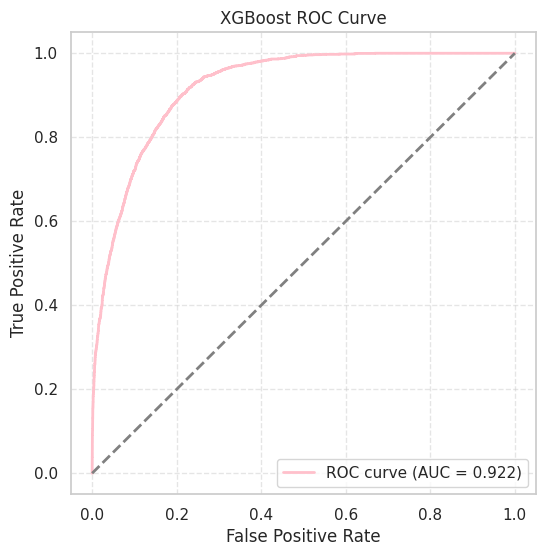

/tmp/ipython-input-3818327670.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance, palette='pastel')


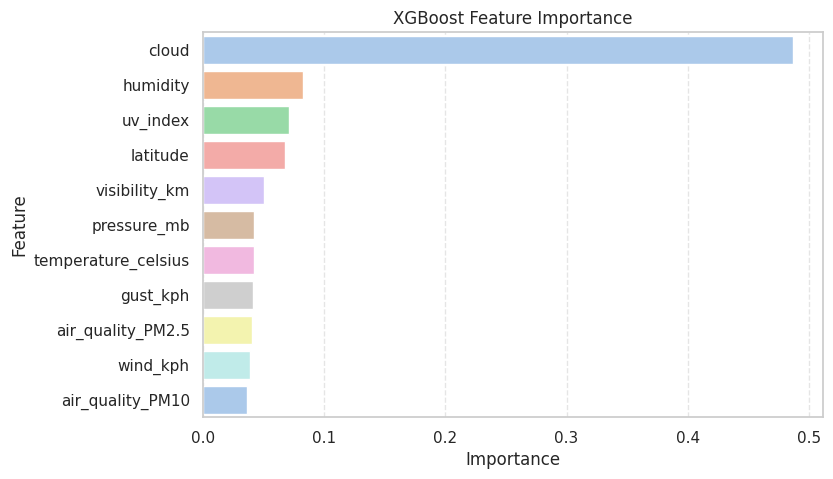

,Feature,Importance
2,cloud,0.487204
1,humidity,0.082830
4,uv_index,0.071118
8,latitude,0.067741
7,visibility_km,0.050396
3,pressure_mb,0.041890
0,temperature_celsius,0.041777
6,gust_kph,0.041454
9,air_quality_PM2.5,0.040248
5,wind_kph,0.039171


In [ ]:
sns.set_palette("pastel")  # consistent color palette

# Target: Rain occurrence
df_no_outliers['rain'] = (df_no_outliers['precip_mm'] > 0).astype(int)

# Features
features = ['temperature_celsius', 'humidity', 'cloud', 'pressure_mb',
            'uv_index', 'wind_kph', 'gust_kph', 'visibility_km',
            'latitude', 'air_quality_PM2.5', 'air_quality_PM10']

X = df_no_outliers[features]
y = df_no_outliers['rain']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# Train
xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("XGBoost Performance:")
capstone_group04.evaluate_classification_model(y_test, y_pred, y_prob)

# -----------------------------
# ROC Curve
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='pink', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='gray', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# -----------------------------
# Feature Importance
# -----------------------------
importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=importance, palette='pastel')
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.show()

display(importance)


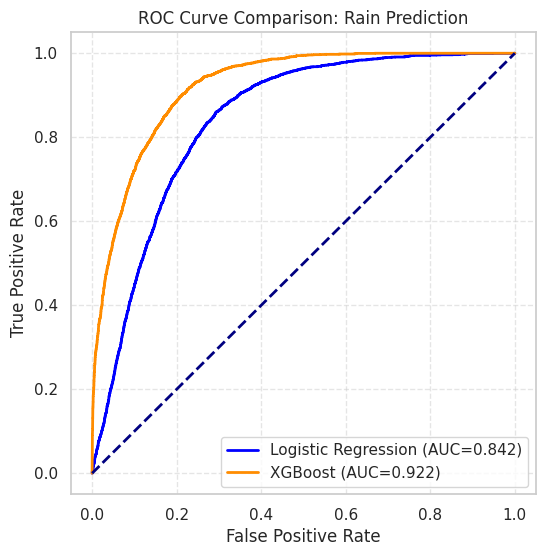

In [ ]:
# Both model comparision
plt.figure(figsize=(6,6))

# Compute values for ROC curve for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, log_reg.predict_proba(X_test_scaled)[:, 1])
auc_lr = auc(fpr_lr, tpr_lr)

# Compute values for ROC curve for XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_model.predict_proba(X_test)[:, 1])
auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (AUC={auc_lr:.3f})')
plt.plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2, label=f'XGBoost (AUC={auc_xgb:.3f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Rain Prediction")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### We classify air quality into Good, Moderate, and Poor categories using a Random Forest Classifier and analyze key influencing variables.

In [ ]:
# Check class distribution
aqi_counts = df_no_outliers['aqi_category'].value_counts()
aqi_percent = df_no_outliers['aqi_category'].value_counts(normalize=True) * 100

print("AQI Category Counts:")
print(aqi_counts)

print("\nAQI Category Percentages:")
print(aqi_percent)


AQI Category Counts:
aqi_category
Good        63073
Moderate     6502
Poor         2650
Name: count, dtype: int64

AQI Category Percentages:
aqi_category
Good        87.328487
Moderate     9.002423
Poor         3.669090
Name: proportion, dtype: float64


Class distribution after SMOTE:
aqi_category
Good        50458
Poor        50458
Moderate    50458
Name: count, dtype: int64
Random Forest AQI Classification Performance (with SMOTE):
              precision    recall  f1-score   support

        Good       0.98      0.90      0.94     12615
    Moderate       0.43      0.74      0.54      1300
        Poor       0.68      0.77      0.72       530

    accuracy                           0.88     14445
   macro avg       0.70      0.80      0.73     14445
weighted avg       0.92      0.88      0.90     14445



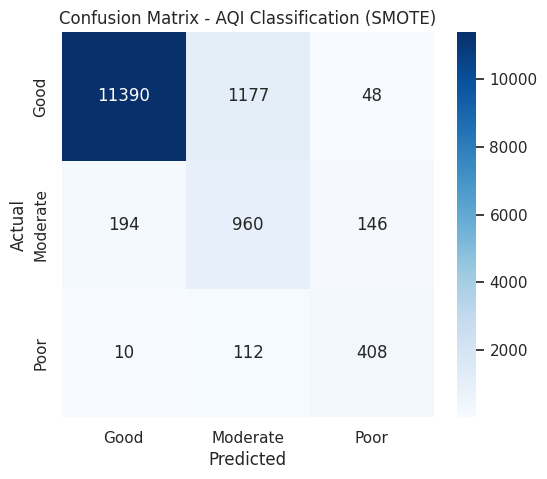

/tmp/ipython-input-2111894167.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances, palette='coolwarm')


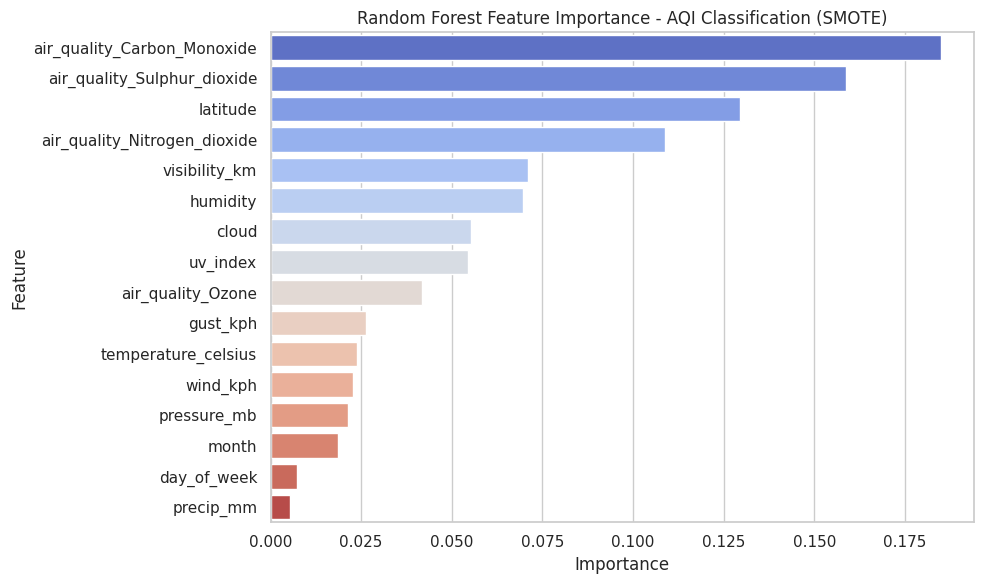


Top Features Influencing AQI Classification:


,Feature,Importance
9,air_quality_Carbon_Monoxide,0.184796
12,air_quality_Sulphur_dioxide,0.158660
13,latitude,0.129606
11,air_quality_Nitrogen_dioxide,0.108763
7,visibility_km,0.071138
1,humidity,0.069730
2,cloud,0.055190
4,uv_index,0.054416
10,air_quality_Ozone,0.041834
6,gust_kph,0.026293


In [ ]:
# Question 4: Can air quality be accurately classified into Good, Moderate, and Poor categories based on weather conditions and pollutant concentrations, and which variables most strongly influence AQI levels?

# ===============================
# Model 4: Random Forest - Air Quality Classification
# ===============================
# -------------------------------
# Define Features and Target
# -------------------------------

# Convert 'last_updated' to datetime and extract month and day of week
df_no_outliers['last_updated'] = pd.to_datetime(df_no_outliers['last_updated'])
df_no_outliers['month'] = df_no_outliers['last_updated'].dt.month
df_no_outliers['day_of_week'] = df_no_outliers['last_updated'].dt.dayofweek

features = [
    'temperature_celsius', 'humidity', 'cloud', 'pressure_mb',
    'uv_index', 'wind_kph', 'gust_kph', 'visibility_km', 'precip_mm',
    'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
    'latitude', 'month', 'day_of_week'
]

X = df_no_outliers[features]
y = df_no_outliers['aqi_category']

# -------------------------------
# Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------
# Handle Imbalance with SMOTE
# -------------------------------
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Class distribution after SMOTE:")
print(y_train_res.value_counts())

# -------------------------------
# Train Random Forest Classifier
# -------------------------------
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    random_state=42
)
rf_model.fit(X_train_res, y_train_res)

# -------------------------------
# Predictions & Evaluation
# -------------------------------
y_pred = rf_model.predict(X_test)

print("Random Forest AQI Classification Performance (with SMOTE):")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['Good', 'Moderate', 'Poor'])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Good', 'Moderate', 'Poor'],
            yticklabels=['Good', 'Moderate', 'Poor'], cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - AQI Classification (SMOTE)')
plt.show()

# -------------------------------
# Feature Importance
# -------------------------------
importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importances, palette='coolwarm')
plt.title("Random Forest Feature Importance - AQI Classification (SMOTE)")
plt.tight_layout()
plt.show()

print("\nTop Features Influencing AQI Classification:")
display(importances.head(10))
